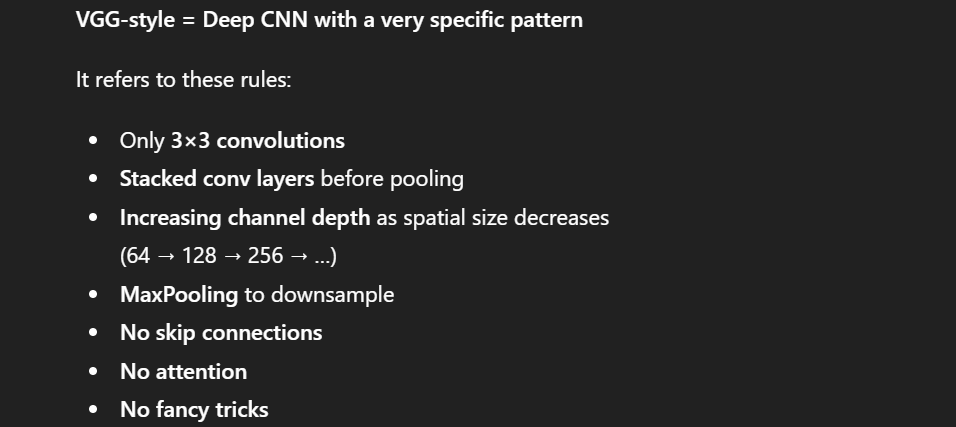

In [38]:
import torch
import torch
from torch import nn
from torch.utils.data import DataLoader , Dataset
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2

In [39]:
device = "cuda" if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [40]:
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

# Preparing and loading the Data

In [41]:
# Download training data from open datasets.

transform_train = v2.Compose([
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToTensor(),   # still needed if dataset returns PIL
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transform_test = v2.Compose([
    v2.ToTensor(),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

training_data = CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform_train
)

# Download test data from open datasets.
test_data = CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform_test

)

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [42]:
training_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [43]:
batch_size = 64 

train_loader = DataLoader(training_data , batch_size=batch_size , shuffle = True )
test_loader  = DataLoader(test_data , batch_size=batch_size , shuffle = True )

In [44]:
X_train , y_train = next(iter(train_loader))
X_test , y_test = next(iter(test_loader))
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

torch.Size([64, 3, 32, 32]) torch.Size([64])
torch.Size([64, 3, 32, 32]) torch.Size([64])


# Creating model architecture

# 📊 VGG-Style Deep CNN

| Layer | Type | Operation              | Kernel / Pool | Stride | Padding | #Maps / Units | Input Size     | Output Size |
| ----- | ---- | ---------------------- | ------------- | ------ | ------- | ------------- | -------------- | ----------- |
| 1     | Conv | Convolution + ReLU     | 3×3           | 1      | 1       | 64            | 3×32×32        | 64×32×32    |
| 2     | Conv | Convolution + ReLU     | 3×3           | 1      | 1       | 64            | 64×32×32       | 64×32×32    |
| 3     | Pool | Max Pooling            | 2×2           | 2      | 0       | —             | 64×32×32       | 64×16×16    |
| 4     | Conv | Convolution + ReLU     | 3×3           | 1      | 1       | 128           | 64×16×16       | 128×16×16   |
| 5     | Conv | Convolution + ReLU     | 3×3           | 1      | 1       | 128           | 128×16×16      | 128×16×16   |
| 6     | Pool | Max Pooling            | 2×2           | 2      | 0       | —             | 128×16×16      | 128×8×8     |
| 7     | Conv | Convolution + ReLU     | 3×3           | 1      | 1       | 256           | 128×8×8        | 256×8×8     |
| 8     | Conv | Convolution + ReLU     | 3×3           | 1      | 1       | 256           | 256×8×8        | 256×8×8     |
| 9     | Pool | Max Pooling            | 2×2           | 2      | 0       | —             | 256×8×8        | 256×4×4     |
| 10    | FC   | Fully Connected + ReLU | —             | —      | —       | 512           | 256×4×4 (4096) | 512         |
| 11    | FC   | Fully Connected        | —             | —      | —       | 10            | 512            | 10          |


In [45]:
class VGG_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1= nn.Sequential(
            nn.Conv2d(3 , 64 , kernel_size=3 , stride=1 , padding = 1 ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64 , 64 , kernel_size=3 , stride=1 , padding = 1 ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2 ,2),
        )
        self.layer_2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2 ,2),
        )
        self.layer_3 = nn.Sequential(
             nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2 ,2)
        )
        self.fc_1 = nn.Sequential(
            nn.Linear(4096, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.35)
        )
                                  
        self.fc_2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)

        x = x.view(x.size(0), -1)
        x = self.fc_1(x)
        x = self.fc_2(x)            

        return x

In [46]:
# Model summary
from torchinfo import summary

summary(
    VGG_CNN(),
    input_size=(1, 3, 32, 32),
    col_names=["input_size", "output_size", "num_params"],
    verbose=1,
);

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
VGG_CNN                                  [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 64, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 64, 32, 32]           1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 32]           [1, 64, 32, 32]           128
│    └─ReLU: 2-3                         [1, 64, 32, 32]           [1, 64, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 64, 32, 32]           [1, 64, 32, 32]           36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 32, 32]           [1, 64, 32, 32]           128
│    └─ReLU: 2-6                         [1, 64, 32, 32]           [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-7                    [1, 64, 32, 32]           [1, 64, 16, 16]           --
├─Sequential: 1-2         

# Training Loop

In [47]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        #  Forward pass
        preds = model(X)
        loss = loss_fn(preds, y)

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

        #  Backward pass
        loss.backward()

        #  Update parameters
        optimizer.step()

        if batch % 100 == 0:
            loss_val = loss.item()
            current = batch * len(X)
            print(f"loss: {loss_val:.6f} [{current}/{size}]")

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

# Testing Loop

In [48]:
def test(dataloader, model, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()

    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # Forward pass
            preds = model(X)
            loss = loss_fn(preds, y)

            # Accumulate loss & accuracy
            test_loss += loss.item()
            correct += (preds.argmax(1) == y).sum().item()

    avg_loss = test_loss / num_batches
    accuracy = correct / size

    print(
        f"Test Error:\n"
        f" Accuracy: {(100 * accuracy):.1f}%\n"
        f" Avg loss: {test_loss:.6f}\n")
    return avg_loss, accuracy

# Training and Parameter

In [52]:
lr = 0.01
epochs = 80
model = VGG_CNN().to(device)
optimizer = torch.optim.AdamW(model.parameters() , lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs)
loss_fn = nn.CrossEntropyLoss()

In [53]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
best_acc = 91.5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    tr_loss, tr_acc = train(train_loader, model, loss_fn, optimizer, device)
    te_loss, te_acc = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    train_accuracies.append(tr_acc)
    test_losses.append(te_loss)
    test_accuracies.append(te_acc)
    
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "VGG_CNN.pth")
print("Done!")

Epoch 1
-------------------------------
loss: 2.394093 [0/50000]
loss: 1.589040 [6400/50000]
loss: 1.308654 [12800/50000]
loss: 1.071974 [19200/50000]
loss: 1.106335 [25600/50000]
loss: 1.004724 [32000/50000]
loss: 1.176522 [38400/50000]
loss: 0.964938 [44800/50000]
Test Error:
 Accuracy: 68.6%
 Avg loss: 141.110209

Epoch 2
-------------------------------
loss: 0.773219 [0/50000]
loss: 0.886196 [6400/50000]
loss: 1.014530 [12800/50000]
loss: 1.037160 [19200/50000]
loss: 0.762236 [25600/50000]
loss: 0.862158 [32000/50000]
loss: 1.157388 [38400/50000]
loss: 0.861992 [44800/50000]
Test Error:
 Accuracy: 74.3%
 Avg loss: 115.373337

Epoch 3
-------------------------------
loss: 0.815289 [0/50000]
loss: 0.700371 [6400/50000]
loss: 0.601172 [12800/50000]
loss: 0.880309 [19200/50000]
loss: 0.782094 [25600/50000]
loss: 1.117622 [32000/50000]
loss: 0.673045 [38400/50000]
loss: 0.445141 [44800/50000]
Test Error:
 Accuracy: 77.5%
 Avg loss: 106.052949

Epoch 4
-------------------------------
los

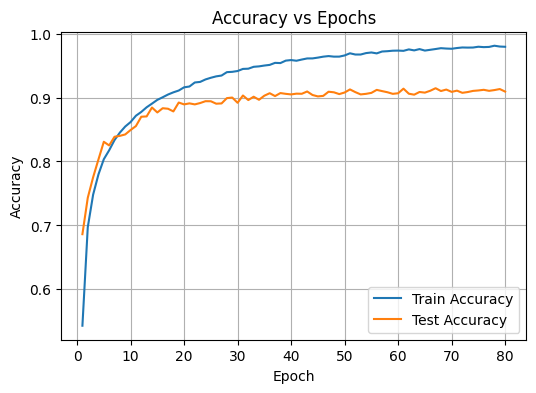

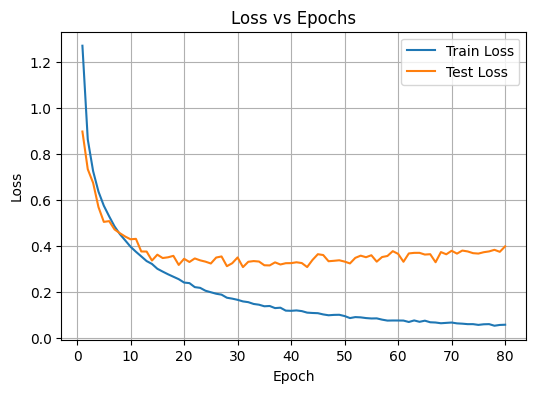

In [54]:
from matplotlib  import pyplot as plt 
epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
wrong_images = []
wrong_preds = []
wrong_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(1)

        mask = preds != y
        if mask.any():
            wrong_images.append(X[mask])
            wrong_preds.append(preds[mask])
            wrong_labels.append(y[mask])

# concatenate
wrong_images = torch.cat(wrong_images)
wrong_preds  = torch.cat(wrong_preds)
wrong_labels = torch.cat(wrong_labels)

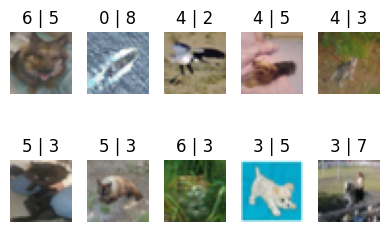

In [56]:

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

plt.figure(figsize=(4,3))
for i in range(10):
    img = wrong_images[i].cpu()                             # (3, 32, 32)
    img = img * std[:, None, None] + mean[:, None, None]    # unnormalize
    

    # CHW -> HWC
    img = img.permute(1, 2, 0).clamp(0, 1)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{wrong_preds[i]} | {wrong_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [57]:
training_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [58]:
from collections import Counter
pairs = list(zip(wrong_labels.tolist(), wrong_preds.tolist()))
print(Counter(pairs).most_common(10))

[((3, 5), 118), ((5, 3), 55), ((8, 0), 33), ((2, 4), 32), ((1, 9), 32), ((3, 6), 27), ((2, 5), 27), ((7, 5), 26), ((4, 5), 23), ((6, 3), 23)]


In [59]:
model = VGG_CNN().to("cpu")                 # recreate SAME architecture
model.load_state_dict(torch.load("VGG_CNN.pth", map_location="cpu"))
model.eval()      

VGG_CNN(
  (layer_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_3): Sequential(
    (0): Conv2d(

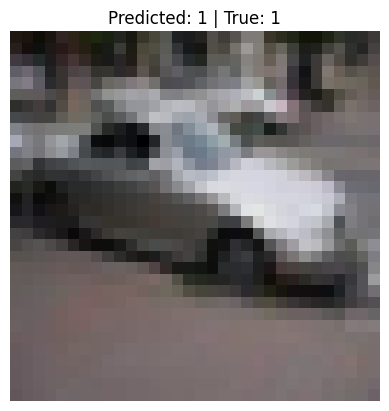

In [60]:
images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0) # (1, 3, H, W)
label = labels[0].item()

with torch.no_grad():
    logits = model(img)
    pred = logits.argmax(dim=1).item()

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

vis_img = images[0] * std[:, None, None] + mean[:, None, None]
vis_img = vis_img.permute(1, 2, 0).clamp(0, 1)

plt.imshow(vis_img)
plt.title(f"Predicted: {pred} | True: {label}")
plt.axis("off")
plt.show()
